In [1]:
import pandas as pd

df = pd.read_csv("/Users/as/Desktop/Project_3_Analytics_System/data/StudentsPerformance.csv")
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [3]:
df.columns = df.columns.str.strip().str.lower().str.replace(" ", "_")

In [4]:
df["total_score"] = df["math_score"] + df["reading_score"] + df["writing_score"]
df["average_score"] = df["total_score"] / 3

In [5]:
df["total_score"] = df["math_score"] + df["reading_score"] + df["writing_score"]
df["average_score"] = df["total_score"] / 3

In [6]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

X = df[["reading_score", "writing_score", "gender", "lunch", "test_preparation_course"]]
X = pd.get_dummies(X, drop_first=True)

y = df["math_score"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)

predictions = model.predict(X_test)

r2_score(y_test, predictions)

0.8810845237281756

In [7]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Impact": model.coef_
})

importance.sort_values(by="Impact", ascending=False)

,Feature,Impact
2,gender_male,13.003536
3,lunch_standard,3.733109
4,test_preparation_course_none,2.843186
1,writing_score,0.644301
0,reading_score,0.314355


In [8]:
from sklearn.tree import DecisionTreeRegressor

In [9]:
tree_model = DecisionTreeRegressor(random_state=42)
tree_model.fit(X_train, y_train)

DecisionTreeRegressor(random_state=42)

In [10]:
tree_model = DecisionTreeRegressor(random_state=42)
tree_model.fit(X_train, y_train)

DecisionTreeRegressor(random_state=42)

In [11]:
tree_predictions = tree_model.predict(X_test)

In [12]:
from sklearn.metrics import r2_score

r2_tree = r2_score(y_test, tree_predictions)
r2_tree

0.6910777793850502

In [13]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(random_state=42)
rf_model.fit(X_train, y_train)

rf_predictions = rf_model.predict(X_test)

r2_rf = r2_score(y_test, rf_predictions)
r2_rf

0.8349694123244231

This project involved data loading, cleaning, feature engineering, analysis, and machine learning modeling. The workflow was rebuilt and optimized to ensure clarity and efficiency.


📊Final Insights

Students who completed the preparation course performed significantly better than those who did not.

Students with standard lunch scored higher on average, indicating the importance of proper nutrition.

Reading and writing scores show a strong positive relationship with math scores.

Most students fall into the medium to good performance category, with fewer extreme low or high performers.

    





    
🤖 Model Insights
    
A Linear Regression model was used to predict math scores based on reading score, writing score, gender, lunch type, and preparation course.

The model achieved an R² score of approximately 0.88, indicating strong predictive performance.

Reading and writing scores were the most influential features in predicting math performance.

Additional factors such as preparation course and lunch type also contributed to improving prediction accuracy.

Compared to Decision Tree, Linear Regression performed better, suggesting that relationships in the data are largely linear.











    
🏫 Business / Real-World Interpretation
    
Schools should emphasize improving reading and writing skills, as they strongly influence overall academic performance.

Encouraging students to take preparation courses can significantly boost performance.

Nutritional support (standard lunch) appears to positively impact student outcomes.

Data-driven strategies can help institutions identify students who need additional support.











    
⚠️ Limitations
    
The dataset does not include key real-world factors such as study hours, attendance, or mental health.

The model assumes linear relationships, which may not capture complex patterns fully.

The dataset size (1000 records) is moderate and may not represent all student populations.

External factors like teaching quality and environment are not considered.










    
    
🚀 Future Improvements
    
Include additional features like study time, attendance, and socio-economic background.

Experiment with advanced models such as Random Forest, XGBoost, or Neural Networks.

Perform hyperparameter tuning to further improve model performance.

Build an interactive dashboard or web app for real-time predictions.

In [16]:
import seaborn as sns
import matplotlib.pyplot as plt

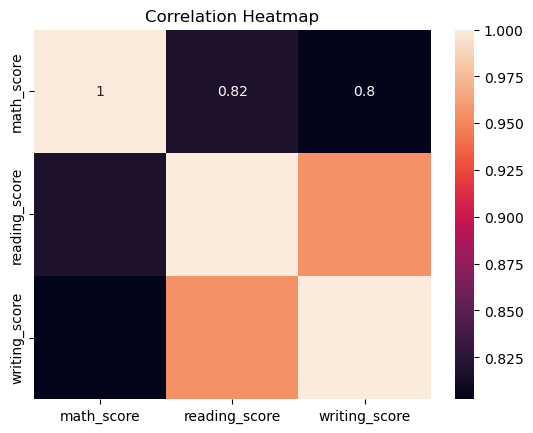

In [18]:
sns.heatmap(df[["math_score","reading_score","writing_score"]].corr(), annot=True)
plt.title("Correlation Heatmap")
plt.show()

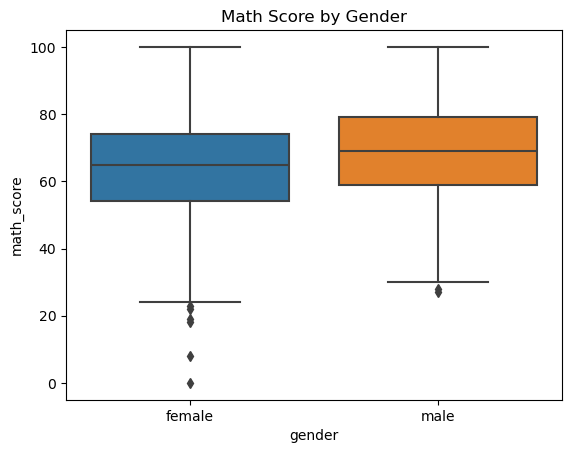

In [19]:
sns.boxplot(x="gender", y="math_score", data=df)
plt.title("Math Score by Gender")
plt.show()

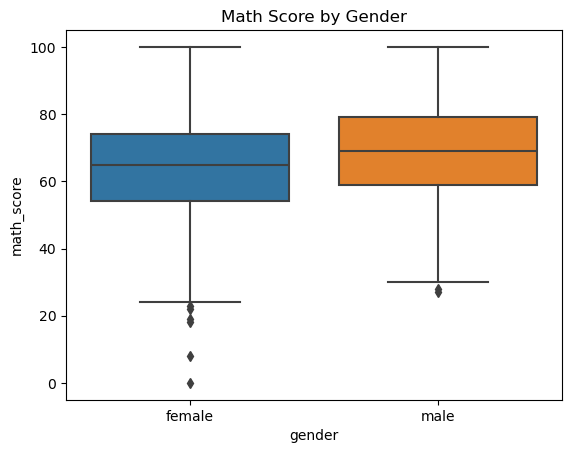

In [20]:
sns.boxplot(x="gender", y="math_score", data=df)
plt.title("Math Score by Gender")
plt.show()

/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


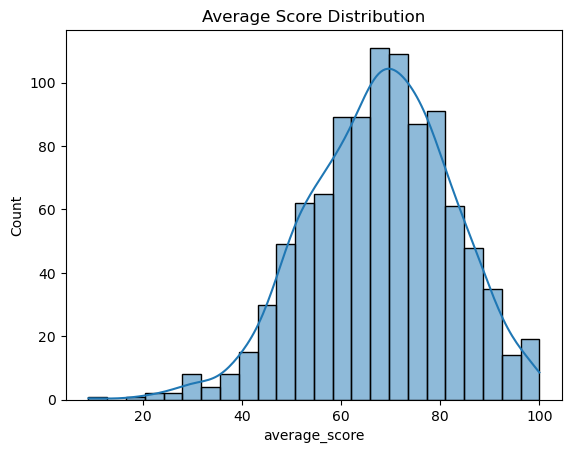

In [21]:
sns.histplot(df["average_score"], kde=True)
plt.title("Average Score Distribution")
plt.show()

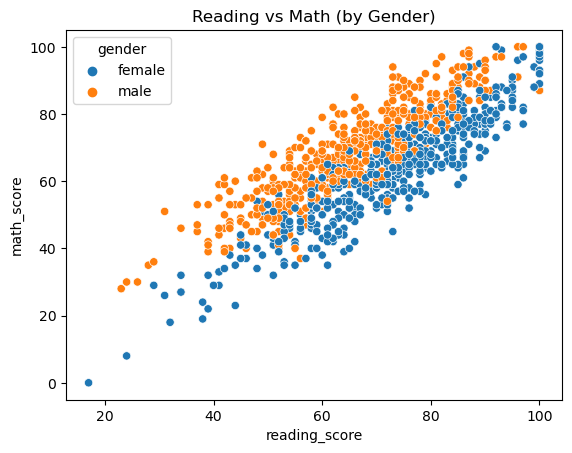

In [22]:
sns.scatterplot(x="reading_score", y="math_score", hue="gender", data=df)
plt.title("Reading vs Math (by Gender)")
plt.show()

In [23]:
Q1 = df["math_score"].quantile(0.25)
Q3 = df["math_score"].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[(df["math_score"] < lower_bound) | (df["math_score"] > upper_bound)]
outliers

,gender,race/ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score,total_score,average_score
17,female,group B,some high school,free/reduced,none,18,32,28,78,26.000000
59,female,group C,some high school,free/reduced,none,0,17,10,27,9.000000
145,female,group C,some college,free/reduced,none,22,39,33,94,31.333333
338,female,group B,some high school,free/reduced,none,24,38,27,89,29.666667
466,female,group D,associate's degree,free/reduced,none,26,31,38,95,31.666667
787,female,group B,some college,standard,none,19,38,32,89,29.666667
842,female,group B,high school,free/reduced,completed,23,44,36,103,34.333333
980,female,group B,high school,free/reduced,none,8,24,23,55,18.333333


In [24]:
outliers.shape

(8, 10)

In [26]:
df_clean = df[(df["math_score"] >= lower_bound) & (df["math_score"] <= upper_bound)]

In [28]:
from sklearn.preprocessing import StandardScaler

In [29]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [30]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

In [31]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [32]:
from sklearn.metrics import r2_score

predictions = model.predict(X_test)
r2_score(y_test, predictions)

0.8810845237281756

In [33]:
from sklearn.linear_model import Ridge

In [34]:
ridge_model = Ridge(alpha=1.0)
ridge_model.fit(X_train, y_train)

Ridge()

In [36]:
ridge_pred = ridge_model.predict(X_test)

In [37]:
from sklearn.metrics import r2_score

r2_ridge = r2_score(y_test, ridge_pred)
r2_ridge

0.8810468189272302

In [38]:
Ridge(alpha=0.1)
Ridge(alpha=10)

Ridge(alpha=10)

In [39]:
from sklearn.linear_model import Lasso

In [40]:
lasso_model = Lasso(alpha=0.1)
lasso_model.fit(X_train, y_train)

Lasso(alpha=0.1)

In [42]:
lasso_pred = lasso_model.predict(X_test)

In [43]:
from sklearn.metrics import r2_score

r2_lasso = r2_score(y_test, lasso_pred)
r2_lasso

0.8800281043784772

In [44]:
pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": lasso_model.coef_
})

,Feature,Coefficient
0,reading_score,4.730510
1,writing_score,9.448142
2,gender_male,6.327727
3,lunch_standard,1.745501
4,test_preparation_course_none,1.188474


In [46]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": lasso_model.coef_
})

importance.sort_values(by="Coefficient", ascending=False)

,Feature,Coefficient
1,writing_score,9.448142
2,gender_male,6.327727
0,reading_score,4.730510
3,lunch_standard,1.745501
4,test_preparation_course_none,1.188474


In [48]:
df.rename(columns={
    "test_preparation_course": "prep_course"
}, inplace=True)

In [49]:
df["average_score"].mean()
df["math_score"].mean()
df.shape[0]
df["prep_course"].value_counts(normalize=True)

prep_course
none         0.642
completed    0.358
Name: proportion, dtype: float64

🔥 BUSINESS INSIGHT 

A large portion of students are not utilizing preparation resources
There is a strong opportunity to improve performance by increasing course participation

🏫 REAL-WORLD MEANING

👉 Schools can:
Encourage more students to take prep courses
Make courses mandatory or more accessible
Improve overall academic performance

📊 Prep Course Insight

Around 64% of students did not complete the preparation course.
Only 36% of students completed it.
Increasing participation in preparation courses could significantly improve student performance.